# Empirical Mode Decomposition (EMD)
 
Data driven approach useful to extract "modes" from a signal. 
 
### Problem
 
It is difficult to get frequency information looking at temporal analysis of a signal (what is amplitude A of frequency F at time T).
 
It is difficult to get temporal information looking at frequency analysis of a signal.
 
We want to know: 

> When does event with a certain frequency occurs in the signal

### Solution

The EMD provides a potential solution to that problem. 

### Algorithm

This notebook contains the general algorithm behind the EMD. 

Variants exist but are not covered by this notebook. 

<IPython.core.display.Javascript object>


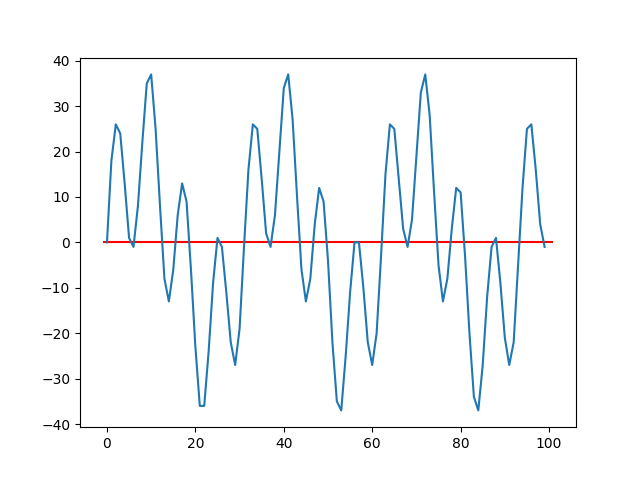

In [351]:
# 1. Get a "random" signal 

import matplotlib.pyplot as plt
%matplotlib notebook

import numpy as np

samples = np.linspace(start=0, stop=20, num=100)
amplitudes = np.sin(samples)
amplitudes *= 20
amplitudes = np.int16(amplitudes)

signal = np.sin((2 ** 2) * samples)
signal *= 20
signal = np.int16(signal)
amplitudes += signal
    
plt.hlines(y=0, xmin=-1, xmax=len(signal)+ 1, colors='red')
plt.plot(amplitudes)

# # Ground truth
# from PyEMD import EMD
# emd = EMD()
# IMFs = emd(amplitudes)
# for imf in IMFs:
#     plt.plot(imf)


<IPython.core.display.Javascript object>


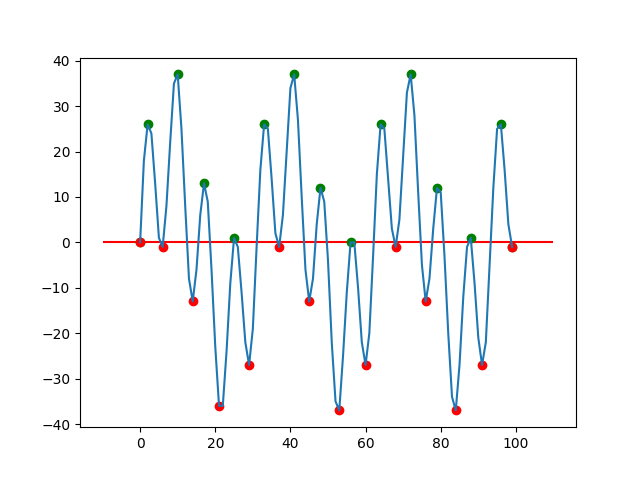

In [352]:
plt.close()
%matplotlib notebook

# 2 Find local extremas

def find_extremas(values):
    maximas = [0]
    minimas = [0]
    previous = False
    for i in range(1, len(values) - 1):
        if values[i - 1] < values[i] >= values[i + 1] and not previous:
            maximas.append(i)
            previous = True
        elif values[i - 1] >= values[i] <= values[i + 1] and not previous:
            minimas.append(i)
            previous = True
            
        else:
            previous = False
    maximas.append(len(values) - 1)
    minimas.append(len(values) - 1)
    return maximas, minimas

maximas, minimas = find_extremas(values=amplitudes)


# Plot the maximas
plt.plot(maximas, amplitudes[maximas], 'go')

# Plot the minimas
plt.plot(minimas, amplitudes[minimas], 'ro')

plt.hlines(y=0, xmin=-10, xmax=len(amplitudes)+ 10, colors='red')
plt.plot(amplitudes)

<IPython.core.display.Javascript object>


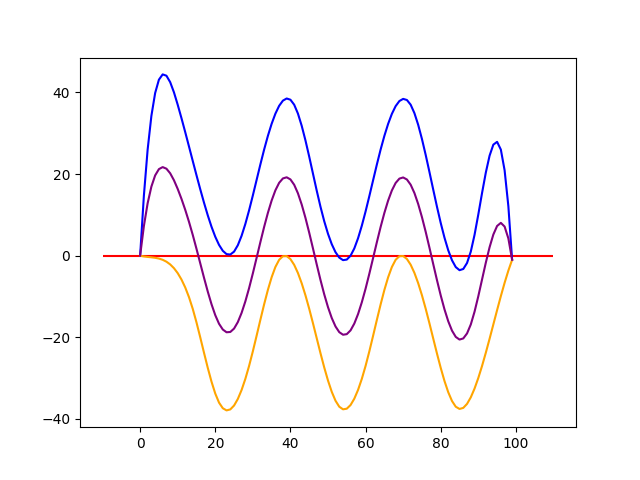

In [353]:
plt.close()
%matplotlib notebook        
from scipy import interpolate

# 3. Interpolate the extremas
def interpolate_extremas(maxs, mins, yvalues):
    space = np.linspace(0, maxs[-1], num=maxs[-1] + 1)
    ymaxs = interpolate.interp1d(maxs, yvalues[maxs], kind='cubic')
    ymaxs = ymaxs(space)
    
    space = np.linspace(0, mins[-1], num=mins[-1] + 1)
    ymins = interpolate.interp1d(mins, yvalues[mins], kind='cubic')
    ymins = ymins(space)
    return ymaxs, ymins
    
interpolated_maxs, interpolated_mins = interpolate_extremas(maximas, minimas, amplitudes) 
interpolated_mins[-1] = interpolated_maxs[-1]
    
# Plot the interpolation
plt.hlines(y=0, xmin=-10, xmax=len(amplitudes)+ 10, colors='red')
plt.plot(interpolated_maxs, color='blue')
plt.plot(interpolated_mins, color='orange')

# 4. Take the mean 
ymean = (interpolated_maxs + interpolated_mins) / 2
plt.plot(ymean, color='purple')

<IPython.core.display.Javascript object>


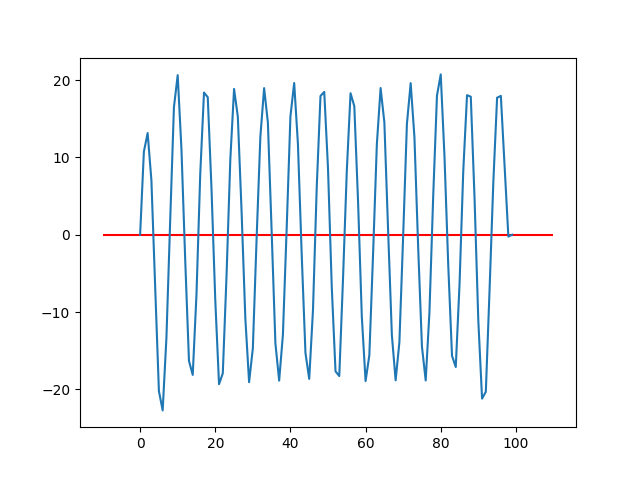

25
Not IMF, keep going!


In [354]:
plt.close()
%matplotlib notebook 

# 5. Compute the residue
new_amplitudes = np.subtract(amplitudes, ymean)


plt.hlines(y=0, xmin=-10, xmax=len(new_amplitudes)+ 10, colors='red')
plt.plot(new_amplitudes)

# 6. Decide whether the residue is an IMF based on:
#    - Symmetric upper/lower envelopes (zero mean, with a tolerance)
#    - Number of zero-crossing and extrema equal +/- 1

def count_zero_crossings(values):
    
    zeros = []
    for i in range(len(values) - 1):
        
        # Naive approach
        if values[i] > 0 and values[i + 1] < 0:
            zeros.append(i)
        elif values[i] < 0 and values[i + 1] > 0:
            zeros.append(i)

    return len(zeros)


zeros = count_zero_crossings(new_amplitudes) 
print(zeros)

criterion = abs((len(maximas) + len(minimas) - 4) - zeros)


if np.mean(new_amplitudes) < 0.1e-3 and criterion <= 1:
    print('IMF!')
else:
    print('Not IMF, keep going!')


<IPython.core.display.Javascript object>


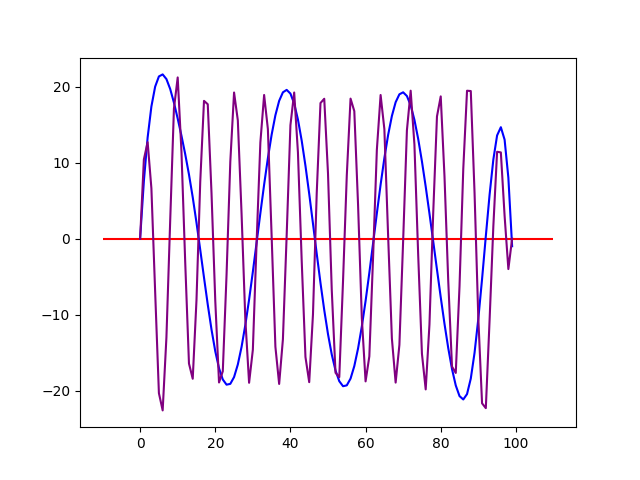

In [355]:
plt.close()
%matplotlib notebook 
plt.hlines(y=0, xmin=-10, xmax=len(amplitudes)+ 10, colors='red')

# 7. Repeat operations until conditions are satisfied

IMFS = []
Means = []
cpt = 0

not_done = True
is_IMF = False

signal = amplitudes
new_amps = new_amplitudes

while not is_IMF and cpt < 1000:

    # Find extremas
    maximas, minimas = find_extremas(values=new_amps)

    # Interpolate extremas
    ymaxs, ymins = interpolate_extremas(maximas, minimas, new_amps)

    # Find mean
    ymean = (ymaxs + ymins) / 2

    # Find residue
    new_amps = new_amps - ymean

    # Count zero crossings
    zeros = count_zero_crossings(new_amps)     
    criterion = abs((len(maximas) + len(minimas) - 4) - zeros)

    if abs(np.mean(new_amps)) < 0.5 and criterion <= 1:
        is_IMF = True
        IMFS.append(new_amps)

    if not is_IMF:
        cpt += 1

signal = signal - new_amps
plt.plot(signal, color='blue')
    
for imf in IMFS:
    plt.plot(IMFS[0], color='purple')
